1.import libraries

In [67]:
#importing the required libraries
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy.stats import randint,uniform


from sklearn.model_selection import GroupShuffleSplit,StratifiedGroupKFold,RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier 

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,class_likelihood_ratios,recall_score,precision_score,f1_score


In [68]:

pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x: f"{x:.3f}")

In [69]:
random_state=42
csv_path=r"C:\Users\swath\Desktop\Projects_MLDL\Capstone_projects\Med-Buddy-ML\dataset\heart.csv"
target_col="target"

2.load data

In [70]:
df = pd.read_csv(csv_path)
print("First 5 rows")
df.head()


First 5 rows


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0


In [71]:
df.shape #shape of the data

(1025, 14)

In [72]:
#finding the missing values

df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

3.EDA

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [74]:
numerical_features=["age","trestbps","chol","thalach","oldpeak","ca"]

categorical_features=["sex","cp","fbs","restecg","exang","slope","thal","target"]

In [75]:
#duplicates

duplicate_mask=df.duplicated()
num_duplicates=duplicate_mask.sum()
print("Number of duplicates rows:",num_duplicates)

#drop duplicates if present

#df=df.drop_duplicates()
#print("Number of rows after dropping duplicats:",df.shape)


Number of duplicates rows: 723


although we have more duplicates we are not removing it as it is an real world data  and if we remove the duplicatesthe we will only have 250-300 data

In [76]:
#target distribution

print("Target distribution:")
print(df[target_col].value_counts())
print("*"*50)
print("Target distribution (normalized):")
print(df[target_col].value_counts(normalize=True)*100)


Target distribution:
target
1    526
0    499
Name: count, dtype: int64
**************************************************
Target distribution (normalized):
target
1   51.317
0   48.683
Name: proportion, dtype: float64


In [77]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000
mean,54.434,0.696,0.942,131.612,246.000,0.149,0.530,149.114,0.337,1.072,1.385,0.754,2.324,0.513
std,9.072,0.460,1.030,17.517,51.593,0.357,0.528,23.006,0.473,1.175,0.618,1.031,0.621,0.500
min,29.000,0.000,0.000,94.000,126.000,0.000,0.000,71.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,48.000,0.000,0.000,120.000,211.000,0.000,0.000,132.000,0.000,0.000,1.000,0.000,2.000,0.000
50%,56.000,1.000,1.000,130.000,240.000,0.000,1.000,152.000,0.000,0.800,1.000,0.000,2.000,1.000
75%,61.000,1.000,2.000,140.000,275.000,0.000,1.000,166.000,1.000,1.800,2.000,1.000,3.000,1.000
max,77.000,1.000,3.000,200.000,564.000,1.000,2.000,202.000,1.000,6.200,2.000,4.000,3.000,1.000


Text(0.5, 1.0, 'Class distribution (0==No Disease) (1==Disease)')

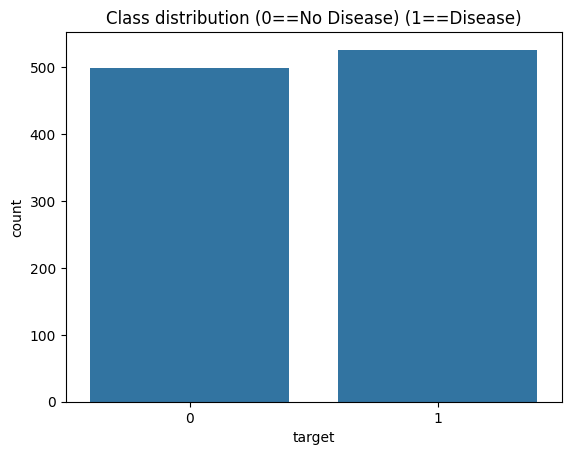

In [78]:
sns.countplot(x=target_col,data=df)
plt.title("Class distribution (0==No Disease) (1==Disease)")

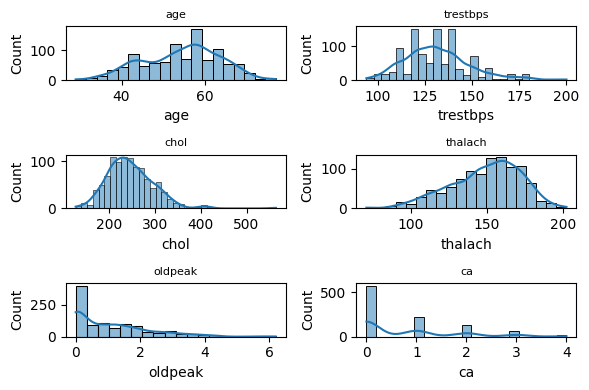

In [79]:
#histogram plot -distribution plot- for numerical features
fig,axes=plt.subplots(3,2,figsize=(6,4))
axes=axes.flatten()

for i,col in enumerate(numerical_features):
    sns.histplot(df[col],kde=True,ax=axes[i])
    axes[i].set_title(col,fontsize=8)
    
plt.tight_layout()
plt.show()

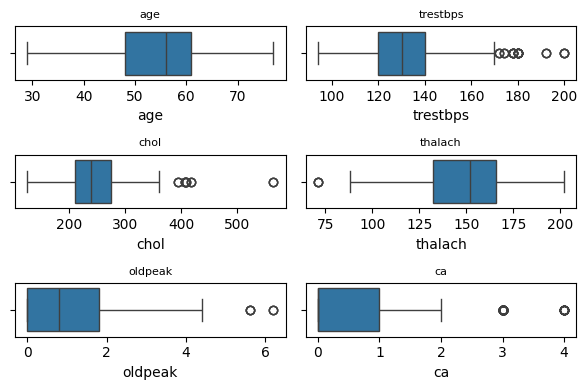

In [80]:
#box plot- for numerical features
fig,axes=plt.subplots(3,2,figsize=(6,4))
axes=axes.flatten()

for i,col in enumerate(numerical_features):
    sns.boxplot(x=df[col],ax=axes[i])
    axes[i].set_title(col,fontsize=8)
    
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlation betweeen numerical columns')

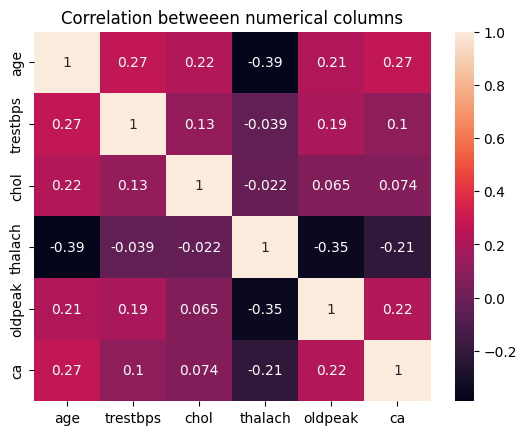

In [81]:
sns.heatmap(df[numerical_features].corr(),annot=True)
plt.title("Correlation betweeen numerical columns")

No highly correlated columns

4. Data Preprocessing

In [82]:
#separating x and y

x=df.drop(target_col,axis=1)
y=df[target_col]

#create a signature for each feature row - to prevent duplicates flow to test set

row_signature=pd.util.hash_pandas_object(x,index=False)

In [83]:
#Splitting the data into train and test sets using GroupShuffleSplit to prevent data leakage due to duplicates

gss=GroupShuffleSplit(
    n_splits=1, #1train test split
    test_size=0.15,
    random_state=42
)

train_idx,test_idx=next(
    gss.split(x,y,groups=row_signature) #similar data will be grouped either in train or in test
)

x_train,x_test=x.iloc[train_idx],x.iloc[test_idx]
y_train,y_test=y.iloc[train_idx],y.iloc[test_idx]

print("Train shape:",x_train.shape)
print("Test shape:",x_test.shape)

Train shape: (869, 13)
Test shape: (156, 13)


In [84]:
print("Dataset size",x.shape)
print("Train shape:",x_train.shape)
print("Test shape:",x_test.shape)

Dataset size (1025, 13)
Train shape: (869, 13)
Test shape: (156, 13)


5. Baseline Model- Logistic Regression

In [85]:
base_pipe=Pipeline(
    [("scaler",StandardScaler()),
     ("model",LogisticRegression())]
)

In [86]:

#training the base pipeline
base_pipe.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [87]:
#reusable evaluation function

def evaluate_classifier(model,x_train,y_train,x_test,y_test,model_name):
    #predictions
    y_train_pred=model.predict(x_train)
    y_test_pred=model.predict(x_test)
    
    
    #accuracy
    train_acc=accuracy_score(y_train,y_train_pred)*100
    test_acc=accuracy_score(y_test,y_test_pred)*100
    
    #results
    
    print(f"{model_name} - Train Accuracy :{train_acc:.2f}%")
    print(f"{model_name} - Test Accuracy :{test_acc:.2f}%")
    
    print("-"*100)
    
    print("Test classification report")
    print(classification_report(y_test,y_test_pred))
    


In [88]:
evaluate_classifier(base_pipe,
                    x_train,
                    y_train,
                    x_test,
                    y_test,
                    "Logistic Regression- Base model")

Logistic Regression- Base model - Train Accuracy :84.23%
Logistic Regression- Base model - Test Accuracy :83.33%
----------------------------------------------------------------------------------------------------
Test classification report
              precision    recall  f1-score   support

           0       0.89      0.71      0.79        69
           1       0.80      0.93      0.86        87

    accuracy                           0.83       156
   macro avg       0.85      0.82      0.83       156
weighted avg       0.84      0.83      0.83       156



Descent performance - can be improved

6. Model selection

In [89]:
#models to evaluate

models={
    "Logistic Regression": LogisticRegression(random_state=random_state),
    "Support vector machine":SVC(random_state=random_state),
    "Random Forest":RandomForestClassifier(random_state=random_state),
    "XGBOOST":XGBClassifier()
}

In [90]:
#cross validation

groups=pd.util.hash_pandas_object(x_train,index=False)
k=5

cv=StratifiedGroupKFold(n_splits=k,shuffle=True,random_state=random_state)

In [91]:
for name, model in models.items():
    recall_scores=[]
    f1_scores=[]
    
    
    for tr_idx,te_idx in cv.split(x_train,y_train,groups=groups):
        x_tr,x_te=x_train.iloc[tr_idx],x_train.iloc[te_idx]
        y_tr,y_te=y_train.iloc[tr_idx],y_train.iloc[te_idx]
        
        pipeline=Pipeline(
            [
                ("scaler",StandardScaler()),
                ("model",model)
            ]
        )
        
        pipeline.fit(x_tr,y_tr)
        pred=pipeline.predict(x_te)
        
        recall_scores.append(round(recall_score(y_te,pred),2))
        f1_scores.append(round(f1_score(y_te,pred),2))
    print("Model Name:",name)
    print("Recall values",recall_scores)
    print("F1 scores",f1_scores)
    
    print("\nCV Recall mean:",round(float(np.mean(recall_scores)),4))
    print("\nCV F1 score mean:",round(float(np.mean(f1_scores)),4))

    print("*"*40)

Model Name: Logistic Regression
Recall values [0.9, 0.75, 0.93, 0.89, 0.82]
F1 scores [0.87, 0.75, 0.91, 0.82, 0.75]

CV Recall mean: 0.858

CV F1 score mean: 0.82
****************************************
Model Name: Support vector machine
Recall values [0.79, 0.72, 0.82, 0.96, 0.72]
F1 scores [0.76, 0.76, 0.84, 0.83, 0.69]

CV Recall mean: 0.802

CV F1 score mean: 0.776
****************************************
Model Name: Random Forest
Recall values [0.93, 0.82, 0.9, 0.92, 0.82]
F1 scores [0.88, 0.81, 0.87, 0.87, 0.75]

CV Recall mean: 0.878

CV F1 score mean: 0.836
****************************************
Model Name: XGBOOST
Recall values [0.82, 0.72, 0.9, 0.97, 0.82]
F1 scores [0.79, 0.78, 0.86, 0.87, 0.72]

CV Recall mean: 0.846

CV F1 score mean: 0.804
****************************************


Random forest classifier provides the highest performance

Hyperparameter Tuning-RFC

In [92]:
rfc_pipe=Pipeline(
    [
        ("scaler",StandardScaler()),
        ("model",RandomForestClassifier(random_state=random_state,n_jobs=-1))
    ]
)

In [99]:
#Parameter distributions
param_dist={
    "model__n_estimators":randint(400,1200),
    "model__max_depth":[3,4,5,6],
    "model__min_samples_split":randint(10,40),
    "model__min_samples_leaf":randint(4,20),
    "model__max_features":[0.25,0.35,0.5,"sqrt"],
    "model__max_samples":uniform(0.6,0.35)
}

In [100]:
#randomized  search
random_search=RandomizedSearchCV(
    estimator=rfc_pipe,
    param_distributions=param_dist,
    n_iter=60,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

In [101]:
#performing tuning
random_search.fit(x_train,y_train,groups=groups)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [3, 4, ...], 'model__max_features': [0.25, 0.35, ...], 'model__max_samples': <scipy.stats....002AED59C8CD0>, 'model__min_samples_leaf': <scipy.stats....002AF31EF6B50>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` fo

In [102]:
print("Hyperparameter Tuning result!")
print("Best parameter:",random_search.best_params_)
print("Best score:",random_search.best_score_)

Hyperparameter Tuning result!
Best parameter: {'model__max_depth': 5, 'model__max_features': 0.35, 'model__max_samples': np.float64(0.7287240964517386), 'model__min_samples_leaf': 7, 'model__min_samples_split': 11, 'model__n_estimators': 597}
Best score: 0.851912108256073


8.Retrain with best parameter

In [103]:
rfc_best=Pipeline(
    [
        ("scaler",StandardScaler()),
        ("model",RandomForestClassifier(random_state=random_state,n_jobs=-1,
                                       n_estimators=random_search.best_params_["model__n_estimators"],
                                       max_depth=random_search.best_params_["model__max_depth"],
                                       min_samples_split=random_search.best_params_["model__min_samples_split"],
                                       min_samples_leaf=random_search.best_params_["model__min_samples_leaf"],
                                       max_features=random_search.best_params_["model__max_features"],
                                       max_samples=random_search.best_params_["model__max_samples"]
                                      )
         )
    ]
)

In [104]:
rfc_best.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",597
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",11


9. Evaluation

In [105]:
print("Random forest - Best model - Train Accuracy: {:.4f}".format(rfc_best.score(x_train, y_train)))
print("Random forest - Best model - Test Accuracy: {:.4f}".format(rfc_best.score(x_test, y_test)))

Random forest - Best model - Train Accuracy: 0.9333
Random forest - Best model - Test Accuracy: 0.8397


In [107]:
classification_rep=classification_report(y_test,rfc_best.predict(x_test))
print("Classification report for the best random forest model:")
print(classification_rep)

Classification report for the best random forest model:
              precision    recall  f1-score   support

           0       0.85      0.77      0.81        69
           1       0.83      0.90      0.86        87

    accuracy                           0.84       156
   macro avg       0.84      0.83      0.84       156
weighted avg       0.84      0.84      0.84       156



10. Build a predictive system

In [108]:
def predict_heart_disease(input_features):
    #create dataframe with correct column names
    input_df=pd.DataFrame([input_features],columns=x_train.columns)
    
    #classs prediction
    prediction=rfc_best.predict(input_df)[0]
    
    #probability prediction (positive class)
    
    probability=rfc_best.predict_proba(input_df)[0][1]
    
    #output
    print(f"Predicted class: {prediction}")
    print(f"Probability of heart disease: {probability:.4f}")
    
    if prediction==1:
        print("Diagnosis: High risk of heart disease")
        
    else:
        print("Diagnosis: Low risk of heart disease")
        
    return prediction,probability

In [109]:
predict_heart_disease({
    "age":60,
    "sex":1,
    "cp":2,
    "trestbps":130,
    "chol":250,
    "thalach":150,
    "oldpeak":2.3,
    "ca":0,
    "slope":1,
    "thal":2
})

Predicted class: 1
Probability of heart disease: 0.5620
Diagnosis: High risk of heart disease


(np.int64(1), np.float64(0.56201992142954))